<a href="https://colab.research.google.com/github/juandavidarcila/Metodos-Computacionales/blob/main/Semana6/CuadraturaGaussLaguerre.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import factorial
import sympy as sym

In [2]:
def GetNewtonMethod(f,df,xn,itmax = 1000, precision=1e-14):

    error = 1.
    it = 0

    while error >= precision and it < itmax:

      dfx = df(xn)

      # Evitar división por cero
      if np.abs(dfx) < 1e-16:
            print("Derivada cercana a cero. Método falla.")
            return False

      xn1 = xn - f(xn)/df(xn)
      error = np.abs( xn1-xn )

      xn  = xn1
      it += 1


    if it == itmax:
        return False
    else:
        return xn

In [3]:
def GetAllRoots(f, df, x, tolerancia_decimales=8, tol_unicidad=1e-6):

    Roots = []

    for x0 in x:

        root = GetNewtonMethod(f, df, x0)

        if root is not False:

            # Redondeamos
            croot = np.round(root, tolerancia_decimales)

            # Verificamos que no esté ya (con tolerancia)
            if not any(np.isclose(croot, r, atol=tol_unicidad) for r in Roots):
                Roots.append(croot)

    Roots = np.array(Roots)
    Roots.sort()

    return Roots

In [4]:
x = sym.Symbol('x',Real=True)

In [5]:
def GetLaguerre(n):

    y = sym.exp(-x) * x**n
    p = sym.exp(x) * sym.diff(y, x, n) / factorial(n)

    return p

In [6]:
Laguerre = []
DLaguerre = []

n=5

for i in range(n+1):

    p = GetLaguerre(i)
    dp = sym.diff(p,x)

    Laguerre.append(p)
    DLaguerre.append(dp)

In [7]:
Laguerre[n]

-0.00833333333333333*x**5 + 0.208333333333333*x**4 - 1.66666666666667*x**3 + 5.0*x**2 - 5.0*x + 1.0

In [8]:
DLaguerre[n]

-0.0416666666666667*x**4 + 0.833333333333333*x**3 - 5.0*x**2 + 10.0*x - 5.0

In [9]:
def GetRootsPolynomial(n,xi,poly,dpoly):


    pn = sym.lambdify([x],poly[n],'numpy')
    dpn = sym.lambdify([x],dpoly[n],'numpy')

    Roots = GetAllRoots(pn,dpn,xi)

    return Roots

In [10]:
xi = np.linspace(1,50,100,dtype=np.longdouble)
Roots = GetRootsPolynomial(n,xi,Laguerre,DLaguerre)
Roots

array([ 0.26356032,  1.41340306,  3.59642577,  7.08581001, 12.64080084],
      dtype=float128)

In [11]:
F = sym.exp(-x)*x**3
F

x**3*exp(-x)

In [12]:
sym.integrate(F,(x,0,sym.oo))

6

In [13]:
# Usando cuadratura de laguerre
Roots, Weights = np.polynomial.laguerre.laggauss(5)
Roots, Weights

(array([ 0.26356032,  1.41340306,  3.59642577,  7.08581001, 12.64080084]),
 array([5.21755611e-01, 3.98666811e-01, 7.59424497e-02, 3.61175868e-03,
        2.33699724e-05]))

In [24]:
f = lambda x: x**3 / (np.exp(1)-1)

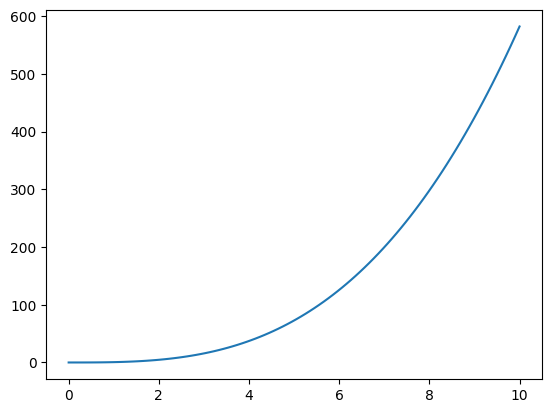

In [25]:
x = np.linspace(0,10,100)
y = f(x)

plt.plot(x,y)
plt.show()

In [15]:
I = np.sum( Weights*f(Roots) )
I

np.float64(6.000000000000005)